<a href="https://colab.research.google.com/github/tomsBifx25/Mus-Glioblastoma-snRNAseq/blob/main/notebooks/Check01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Single-Nucleus Transcriptomics of Glioblastoma Across the Lifespan
****
*Thomas Walsh | March 18, 2026*

Hood College
*   BIFX 546 — Machine Learning for Bioinformatics, Spring 2026
*   Instructor: Dr. Sarangan (Ravi) Ravichandran
****
**Dataset**

Name: longevity-db/mouse-glioblastoma-snRNAseq

Source: https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq | CELLxGENE | GEO: GSE186252
****
**Project Goals**

How does the age-dependent Tumor microenvironment diverge in glioblastoma contexts between young and aged mice?

Aging is the primary risk factor for glioblastoma (GBM) and
significantly correlates with poorer prognosis. While much research focuses on the tumor's genetic mutations, the age-dependent microenvironment remains under-explored. This dataset is unique because it provides high-resolution, single-nucleus RNA sequencing (snRNA-seq) across "young" and "aged" cohorts, allowing for a granular look at how the aging brain environment modulates cancer progression and immune evasion.

# Loading the Data
Loading the dataset from Hugging Face using the `datasets` library.
First, it may be necessary to install `datasets` library in colab.

In [ ]:
pip install datasets

Although optional, it's recommended to setup a Hugging Face Token for colab to allow for more efficent loading times.

Accessing the Hugging face token key from colab after inital setup:

In [ ]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

Now, loading the dataset using `load_dataset` and inspect its structure. The dataset ID from Hugging Face is `longevity-db/mouse-glioblastoma-snRNAseq`.

**Recommended loading method from the dataset's README on Hugging Face.**

I used a streamed verison in order to subset the data to make it more managable for colab.

In [ ]:
# May take ~30secs to run
from datasets import load_dataset
import pandas as pd

dataset_name = "longevity-db/mouse-glioblastoma-snRNAseq"

try:
    # Load the dataset in streaming mode
    # This allows processing data without loading the entire dataset into memory
    # which is ideal for getting a 'smaller, more manageable portion'.
    streamed_dataset = load_dataset(dataset_name, streaming=True)

    # Assuming there's a 'train' split, we'll take the first 10000 examples.
    # You can adjust this number as needed.
    sample_size = 10000
    sampled_data = []
    for i, example in enumerate(streamed_dataset['train']):
        if i >= sample_size:
            break
        sampled_data.append(example)

    # Convert the sampled data to a Pandas DataFrame for easier manipulation
    df_sampled = pd.DataFrame(sampled_data)

    print(f"Successfully loaded a sample of {len(df_sampled)} examples.")
    print("\nFirst 5 rows of the sampled data:\n")
    display(df_sampled.head())

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the dataset ID is correct, you have network access, and the HF_TOKEN (if required) is set in Colab secrets.")

Successfully loaded a sample of 10000 examples.

First 5 rows of the sampled data:



,nCount_RNA,nFeature_RNA,sub_celltype,assay_ontology_term_id,organism_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,is_primary_data,self_reported_ethnicity_ontology_term_id,sex_ontology_term_id,...,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,n_genes,cell_id
0,1113.0,591,Astrocyte,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,UrkBeMgX@4,588,3920-19_AAACCCACAAACACCT-1
1,1417.0,755,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,@x{bDyo8WK,754,3920-19_AAACCCAGTCCAACGC-1
2,8532.0,3448,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,za~S?77j{3,3441,3920-19_AAACCCAGTGCGTTTA-1
3,8987.0,3554,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,jm43>$?2c0,3546,3920-19_AAACCCAGTGGATACG-1
4,1669.0,951,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,Y^c3RkVgoa,946,3920-19_AAACCCATCCTATTGT-1


**Making Sense of the data.**

The following columns are the most relevant to our research question:
* nCount_RNA - the number of reads
* nFeature_RNA - the number of genes
* sub_celltype - the type of cell sample
* assay - technology used to sequence the library
* disease - *should all be glioblasmoa*
* organism - *should all be mouse*
* sex - either female or male
* tissue - *should all be brain tissues*
* development_stage -  2-month-old (*should have older subset as well*)

# Initial Cleaning:

From the subset, check for any missing values:

In [ ]:
print("Checking for missing values in df_sampled per column:")

found_missing_values = False
for col in df_sampled.columns:
  null_count = df_sampled[col].isnull().sum()
  if null_count > 0:
    print(f"Column '{col}': {null_count} missing values")
    found_missing_values = True

if not found_missing_values:
  print("No missing values found in df_sampled.")

Checking for missing values in df_sampled per column:
No missing values found in df_sampled.


**Next, check for unique values**

For each column, if there is only one unique value, remove it and place into a new data frame for single values.

The single unique values may help us to understand the dataset, so I didn't want to delete them but their removal will help to isolate useful data for analysis

In [ ]:
import pandas as pd

single_values_data = {}
cols_to_drop = []

for col in df_sampled.columns:
    unique_vals = df_sampled[col].unique()
    if len(unique_vals) > 1:
        print(f"Column '{col}': There's more than one unique value.")
    else:
        single_values_data[col] = unique_vals[0] # Store the single unique value
        cols_to_drop.append(col) # Mark column for removal
        print(f"Column '{col}': Unique value is '{unique_vals[0]}'")

# Create a new DataFrame for columns with single unique values
df_single_unique_values = pd.DataFrame.from_dict(single_values_data, orient='index', columns=['Unique Value'])
print("\nDataFrame with single unique values:")
display(df_single_unique_values)

# Remove these columns from df_sampled
df_sampled = df_sampled.drop(columns=cols_to_drop)
print("\nOriginal df_sampled after removing columns with single unique values:")
display(df_sampled.head())

Column 'nCount_RNA': There's more than one unique value.
Column 'nFeature_RNA': There's more than one unique value.
Column 'sub_celltype': There's more than one unique value.
Column 'assay_ontology_term_id': Unique value is 'EFO:0009922'
Column 'organism_ontology_term_id': Unique value is 'NCBITaxon:10090'
Column 'development_stage_ontology_term_id': Unique value is 'MmusDv:0000062'
Column 'disease_ontology_term_id': Unique value is 'MONDO:0018177'
Column 'is_primary_data': Unique value is 'True'
Column 'self_reported_ethnicity_ontology_term_id': Unique value is 'na'
Column 'sex_ontology_term_id': There's more than one unique value.
Column 'suspension_type': Unique value is 'cell'
Column 'tissue_type': Unique value is 'tissue'
Column 'tissue_ontology_term_id': Unique value is 'UBERON:0000955'
Column 'sample_id': There's more than one unique value.
Column 'groupid': Unique value is 'Nf1'
Column 'donor_id': There's more than one unique value.
Column 'author_celltype': There's more than o

,Unique Value
assay_ontology_term_id,EFO:0009922
organism_ontology_term_id,NCBITaxon:10090
development_stage_ontology_term_id,MmusDv:0000062
disease_ontology_term_id,MONDO:0018177
is_primary_data,True
self_reported_ethnicity_ontology_term_id,na
suspension_type,cell
tissue_type,tissue
tissue_ontology_term_id,UBERON:0000955
groupid,Nf1



Original df_sampled after removing columns with single unique values:


,nCount_RNA,nFeature_RNA,sub_celltype,sex_ontology_term_id,sample_id,donor_id,author_celltype,cell_type_ontology_term_id,cell_type,sex,observation_joinid,n_genes,cell_id
0,1113.0,591,Astrocyte,PATO:0000383,3920-19,Nf1.mGBM.1,Astrocyte,CL:0000127,astrocyte,female,UrkBeMgX@4,588,3920-19_AAACCCACAAACACCT-1
1,1417.0,755,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,@x{bDyo8WK,754,3920-19_AAACCCAGTCCAACGC-1
2,8532.0,3448,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,za~S?77j{3,3441,3920-19_AAACCCAGTGCGTTTA-1
3,8987.0,3554,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,jm43>$?2c0,3546,3920-19_AAACCCAGTGGATACG-1
4,1669.0,951,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,Y^c3RkVgoa,946,3920-19_AAACCCATCCTATTGT-1


# Visualizations
**Scatter plots**

A basic scatter plot for Count Reads and Genes:

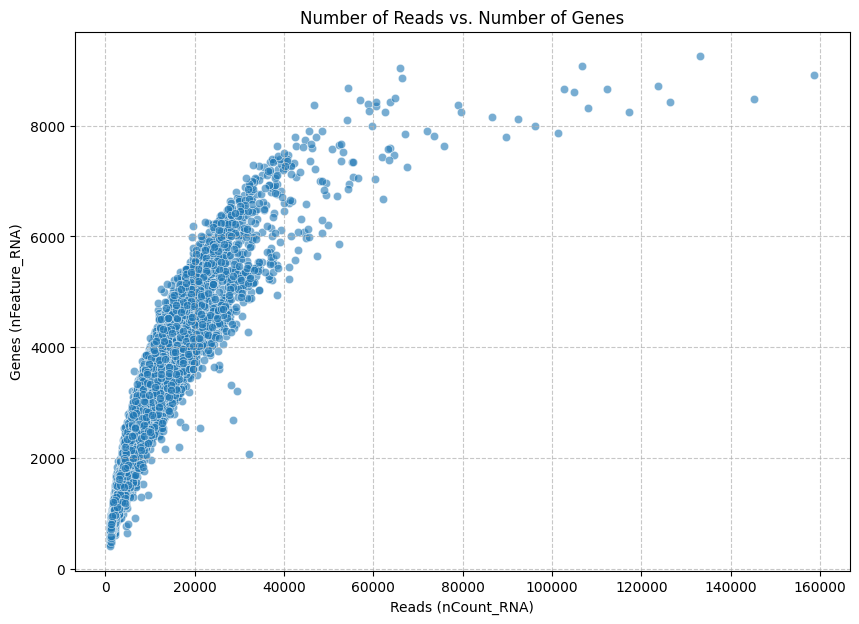

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate basic scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', data=df_sampled, alpha=0.6)

# plot labels
plt.title('Number of Reads vs. Number of Genes')
plt.xlabel('Reads (nCount_RNA)')
plt.ylabel('Genes (nFeature_RNA)')

plt.grid(True, linestyle='--', alpha=0.7)

# display plot
plt.show()

This scatter plot shows the relationship between `nCount_RNA` (number of reads) and `nFeature_RNA` (number of genes). Typically, a positive correlation is expected, meaning as the number of reads increases, the number of detected genes also tends to increase.

This helps to observe the general trend between these two metrics.

**Scatter plot by cell types:**

For a deeper understanding about the differences the number od reads and the number of genes, we can color by cell type.

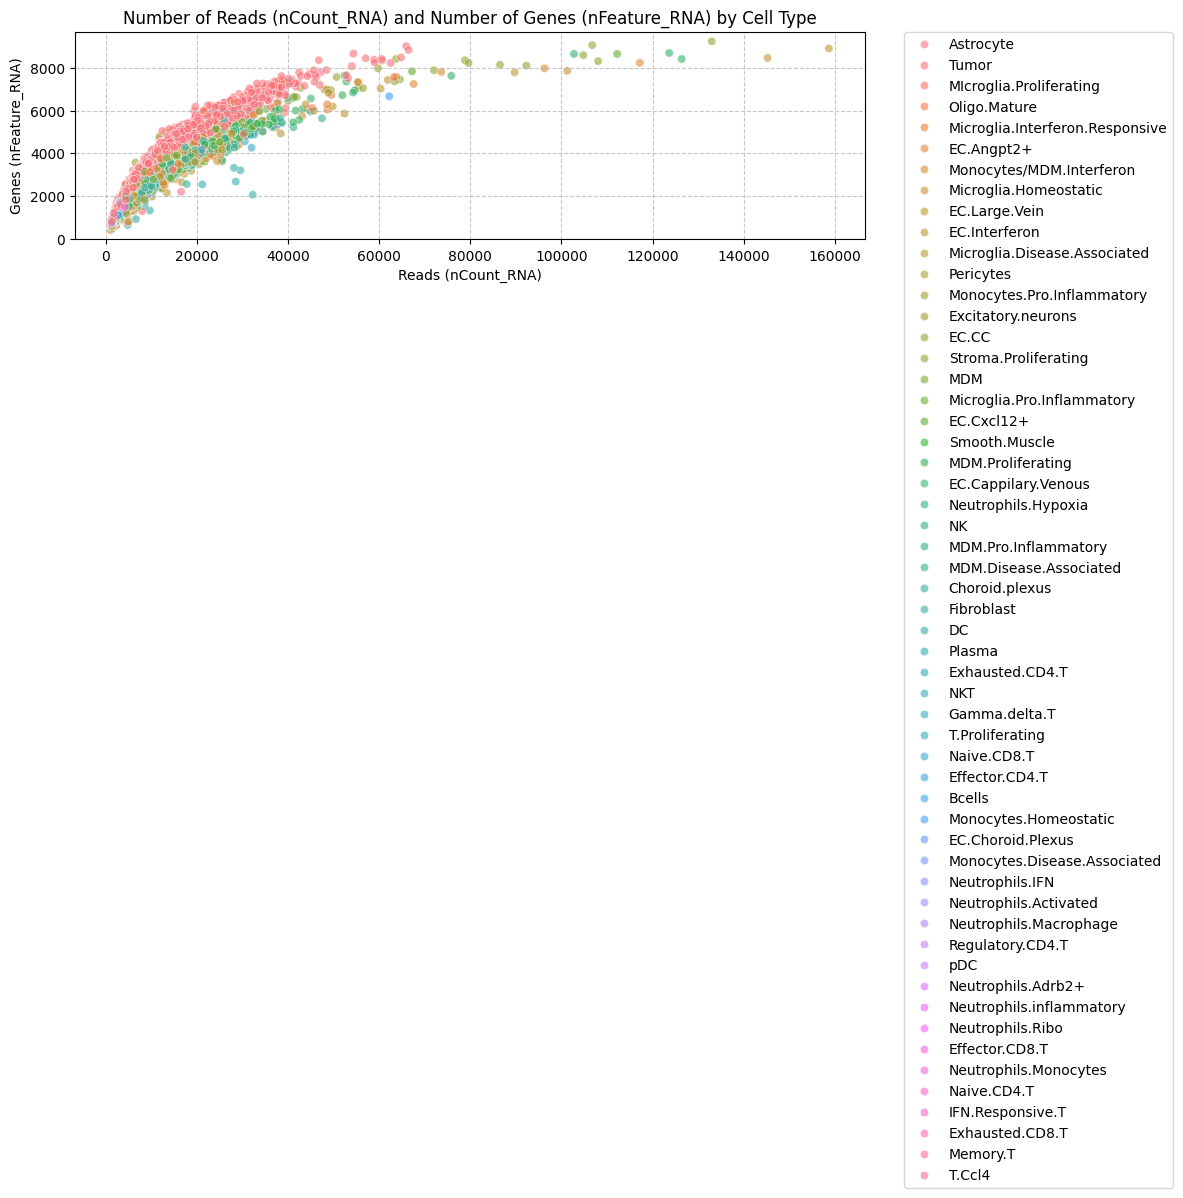

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate scatter plot
plt.figure(figsize=(12, 8)) # Increased figure size for better readability with more colors
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', hue='sub_celltype', data=df_sampled, alpha=0.6)

# Title and labels
plt.title('Number of Reads (nCount_RNA) and Number of Genes (nFeature_RNA) by Cell Type')
plt.xlabel('Reads (nCount_RNA)')
plt.ylabel('Genes (nFeature_RNA)')

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Move the legend outside the plot area to prevent overlapping with data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off

# Display the plot
plt.show()

This scatter plot shows the relationship between `nCount_RNA` and `nFeature_RNA` as before, but colored by cell type.

This helps to visualize which cell types have more expression. As expected, the Astrocyte and "Tumor" cell type (pink) have higher expression levels when compared to other cell types. For this dataset the "tumor" designation is for Glioblastoma.



**Plotting the Number of Reads and Genes by Sex**

There is a relatively even distribution between Female and Male observations, 42.1% Female and 57.8% Male:

In [ ]:
print(df_sampled['sex'].value_counts())

sex
female    5787
male      4213
Name: count, dtype: int64


**Scatter plot for Reads and Genes by Sex:**

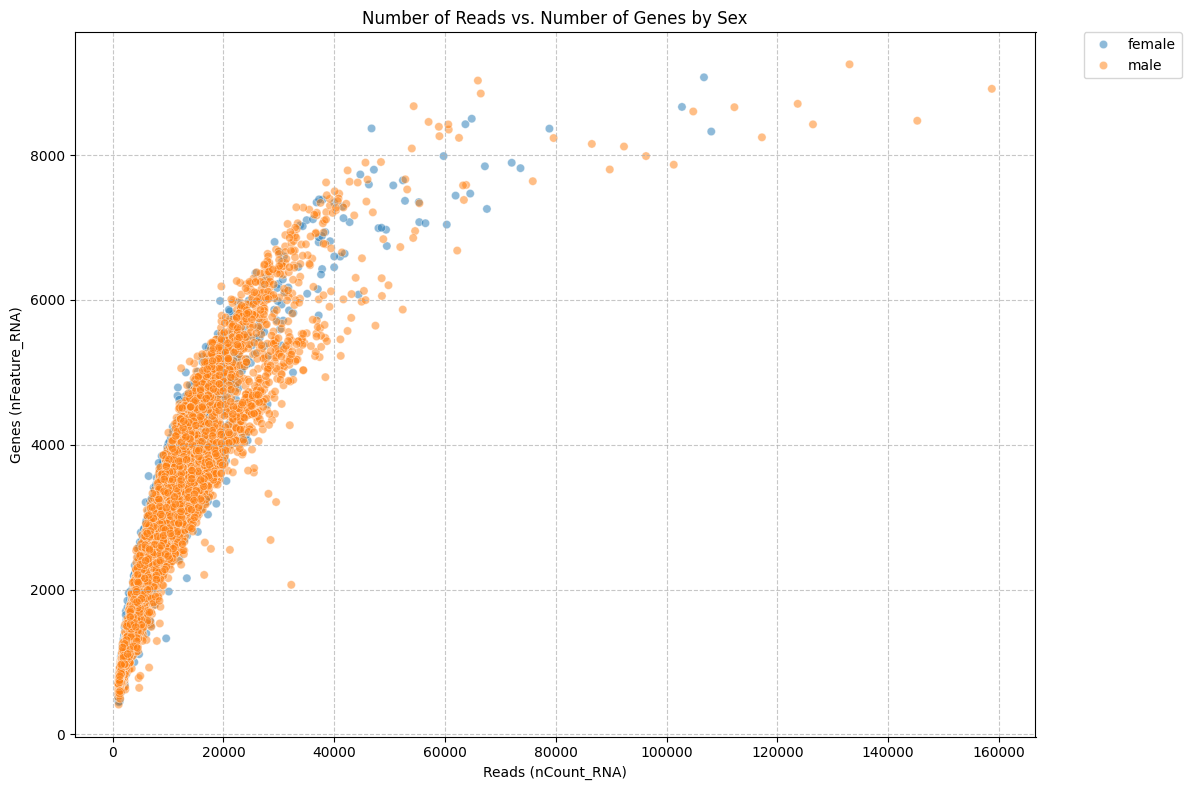

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate scatter plot colored by 'sex'
plt.figure(figsize=(12, 8))
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', hue='sex', data=df_sampled, alpha=0.5)

# Plot labels
plt.title('Number of Reads vs. Number of Genes by Sex')
plt.xlabel('Reads (nCount_RNA)')
plt.ylabel('Genes (nFeature_RNA)')

plt.grid(True, linestyle='--', alpha=0.7)

# Move the legend outside the plot area for better readability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

# Display plot
plt.show()

**Filter Data by Sex**

To plot both Female and Male next to eachother so theyy don't overlap, I needed to filter the `df_sampled` DataFrame into filter the `df_sampled` DataFrame into `df_female` and `df_male` based on the `sex` column, I will use boolean indexing.

In [ ]:
df_female = df_sampled[df_sampled['sex'] == 'female']
df_male = df_sampled[df_sampled['sex'] == 'male']

print(f"df_female created with {len(df_female)} observations.")
print(f"df_male created with {len(df_male)} observations.")

df_female created with 5787 observations.
df_male created with 4213 observations.


**Plotting Reads and Genes by Sex**

Side-by-side scatter plots:

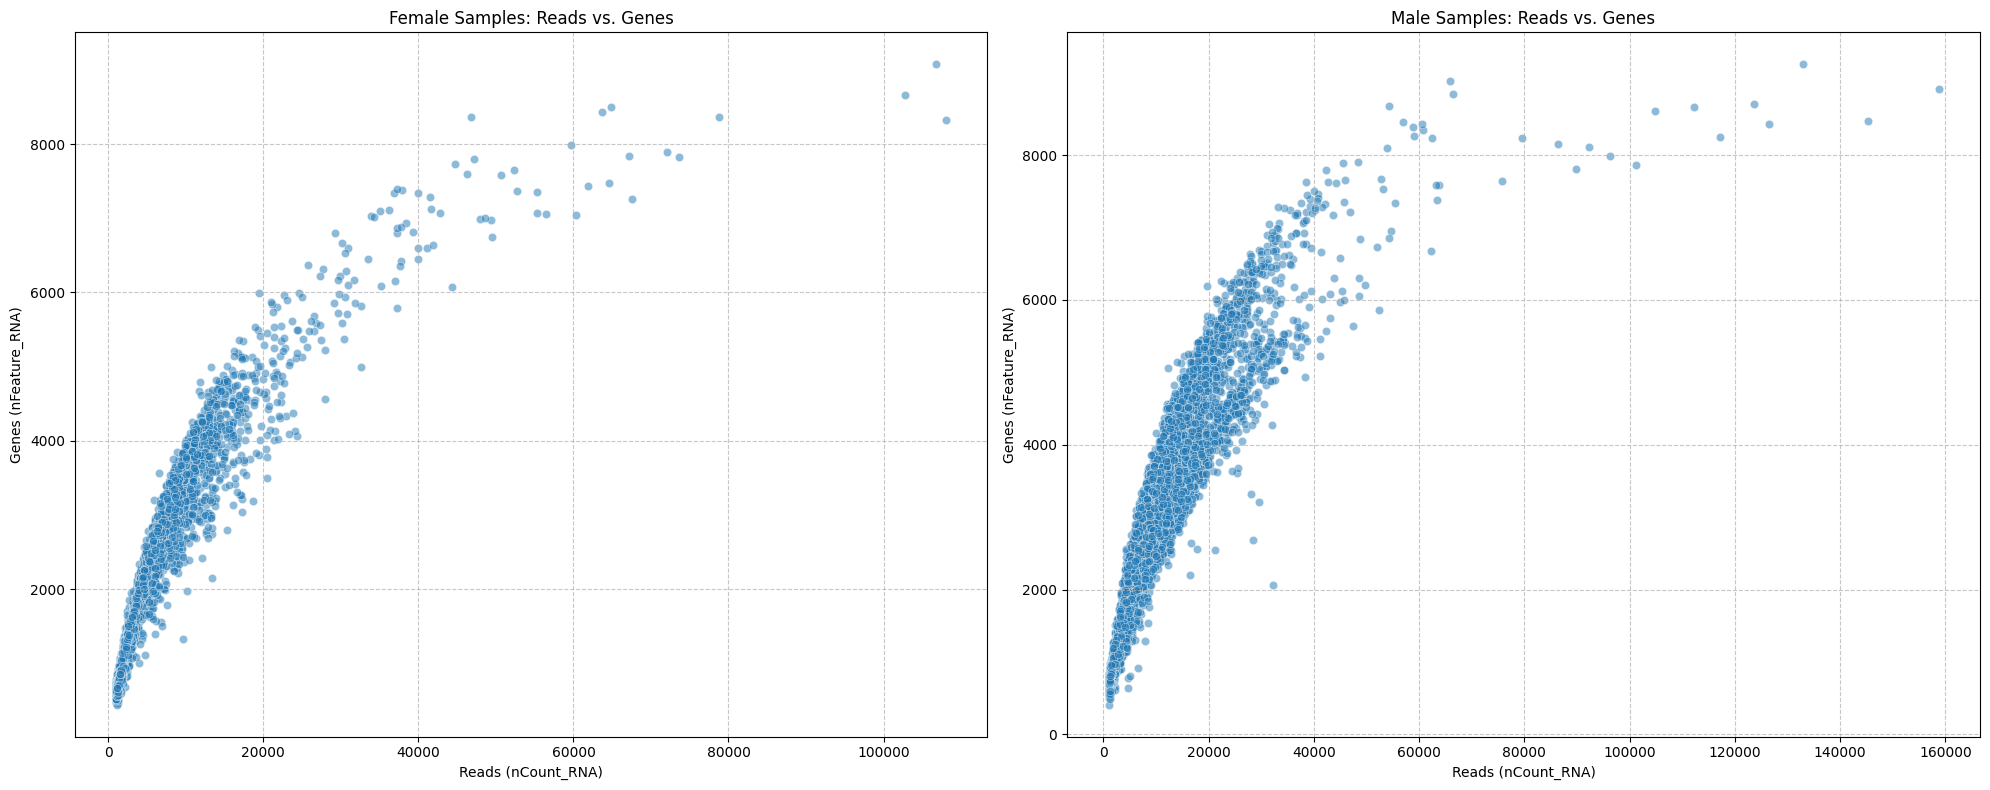

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots arranged side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot for Female samples (df_female)
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', data=df_female, ax=axes[0], alpha=0.5)
axes[0].set_title('Female Samples: Reads vs. Genes')
axes[0].set_xlabel('Reads (nCount_RNA)')
axes[0].set_ylabel('Genes (nFeature_RNA)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Male samples (df_male)
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', data=df_male, ax=axes[1], alpha=0.5)
axes[1].set_title('Male Samples: Reads vs. Genes')
axes[1].set_xlabel('Reads (nCount_RNA)')
axes[1].set_ylabel('Genes (nFeature_RNA)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

The plots suggest that the fundamental relationship between sequencing depth and gene detection is consistent across sexes.

**Distribution of the number of Reads and Genes for each Cell Type**

To visualize how the `nCount_RNA` (number of reads) and `nFeature_RNA` (number of genes) differ across different cell types, we can use violin plots based on the `sub_celltype` column.

**The Reads (`nCount_RNA`) for each Cell Type (`sub_celltype`)**

To visualize the distribution of 'nCount_RNA' for each 'sub_celltype', a violin plot is suitable. I will use `seaborn.violinplot` to create this plot, ensuring proper labels, title, and layout adjustments for readability.

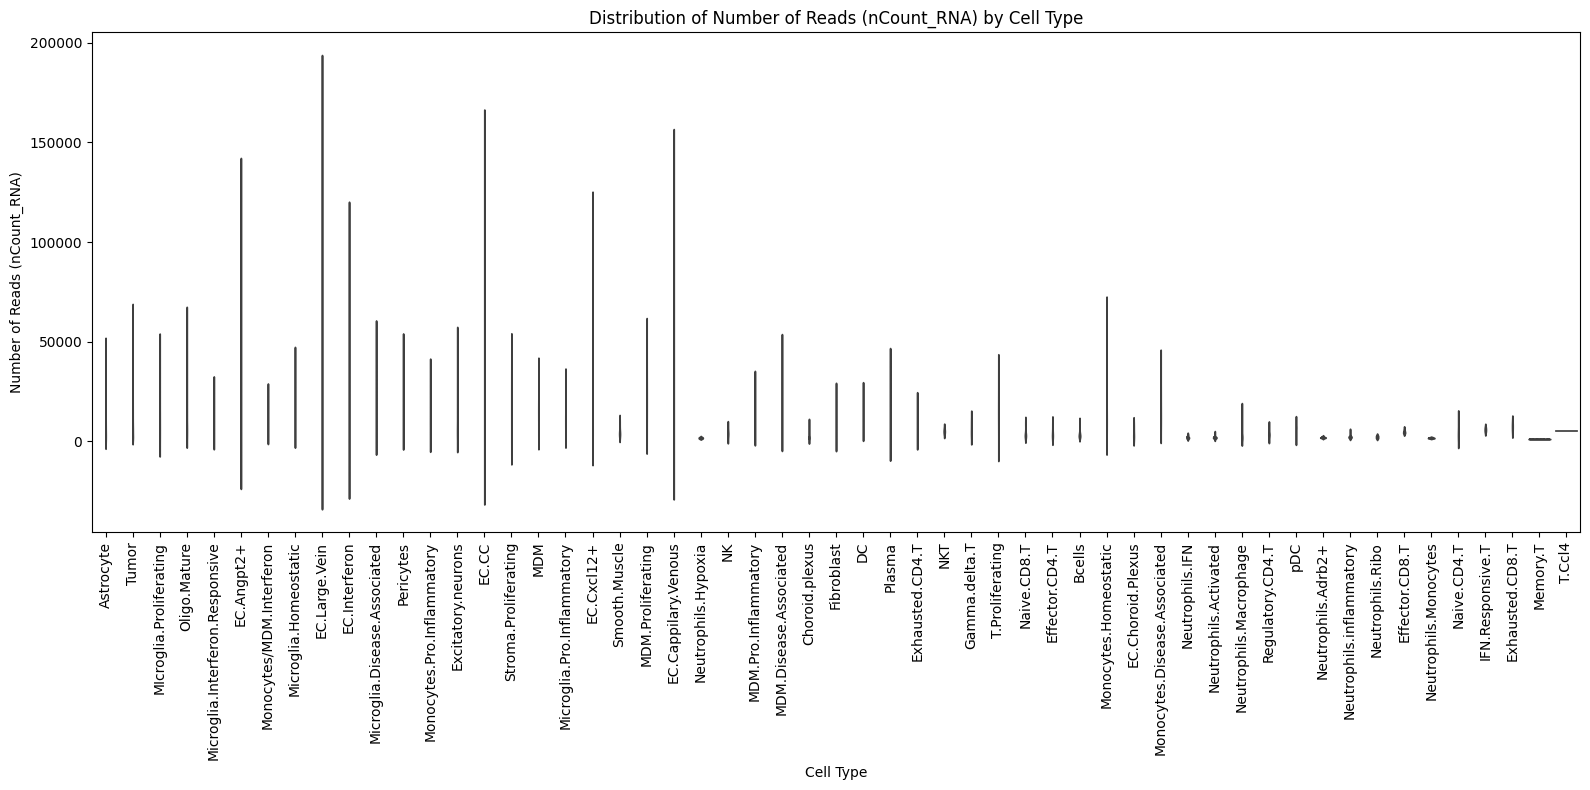

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure and axes for the plot with an appropriate size
plt.figure(figsize=(16, 8)) # Increased figure size to accommodate many cell types

# Generate violin plot
sns.violinplot(x='sub_celltype', y='nCount_RNA', data=df_sampled, inner='quartile')

# Title and labels
plt.title('Distribution of Number of Reads (nCount_RNA) by Cell Type')
plt.xlabel('Cell Type')
plt.ylabel('Number of Reads (nCount_RNA)')

# Rotate the x-axis labels if they are overlapping to improve readability
plt.xticks(rotation=90)

# Adjust the plot layout to prevent elements from being cut off
plt.tight_layout()

# Display the plot
plt.show()

**The Genes (`nFeature_RNA`) for each Cell Type (`sub_celltype`)**

To visualize the distribution of 'nFeature_RNA' for each 'sub_celltype', a violin plot is suitable. I will use `seaborn.violinplot` to create this plot, ensuring proper labels, title, and layout adjustments for readability, similar to the previous plot.

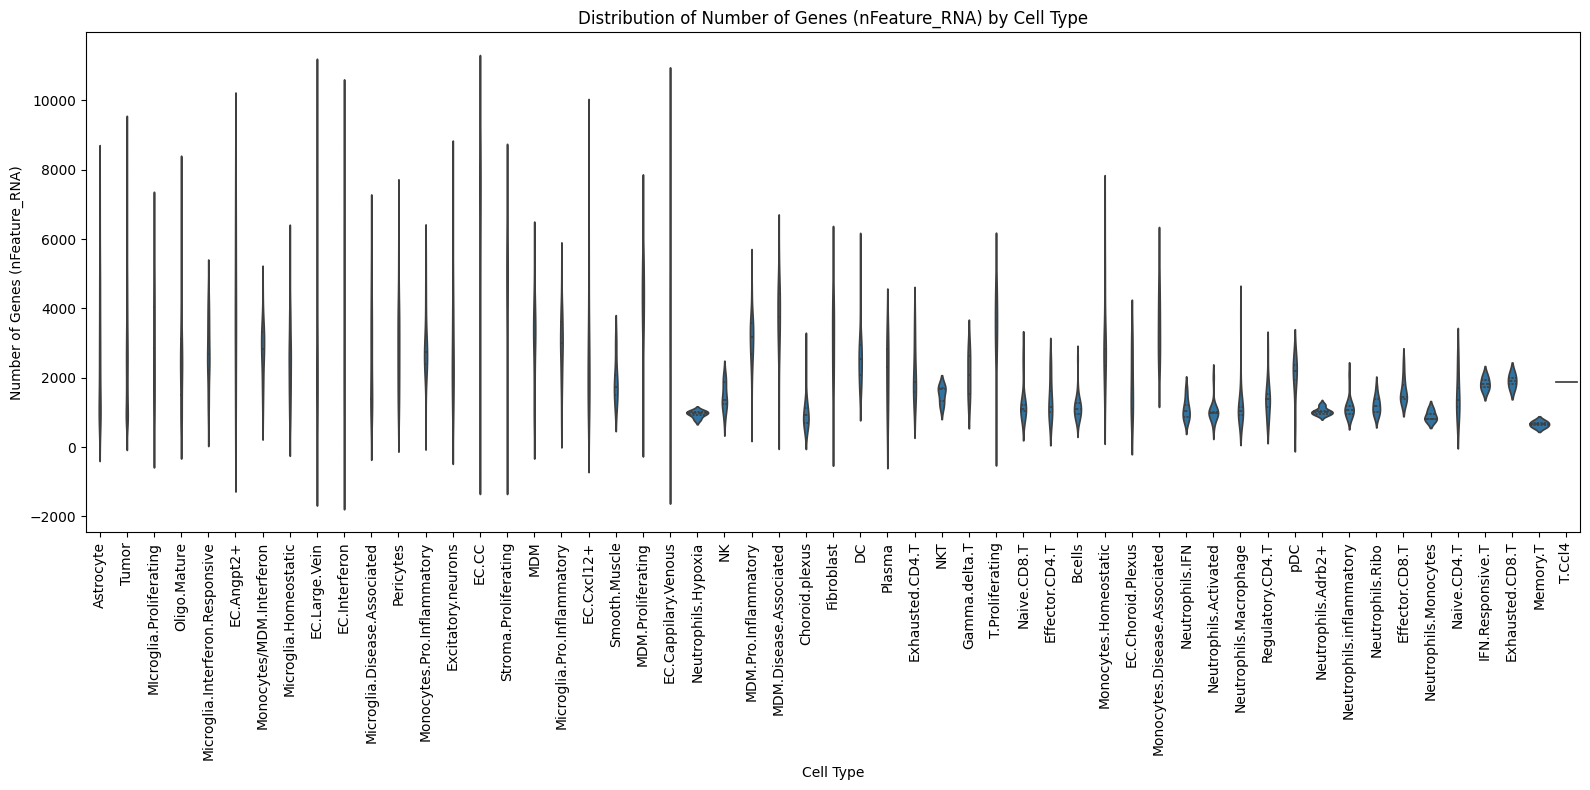

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axes for the plot with an appropriate size
plt.figure(figsize=(16, 8)) # Increased figure size to accommodate many cell types

# Generate a violin plot
sns.violinplot(x='sub_celltype', y='nFeature_RNA', data=df_sampled, inner='quartile')

# Add a title to the plot
plt.title('Distribution of Number of Genes (nFeature_RNA) by Cell Type')

# Label the x-axis and y-axis
plt.xlabel('Cell Type')
plt.ylabel('Number of Genes (nFeature_RNA)')

# Rotate the x-axis labels if they are overlapping to improve readability
plt.xticks(rotation=90)

# Adjust the plot layout to prevent elements from being cut off
plt.tight_layout()

# Display the plot
plt.show()

**Observations from Violin Plots:**

The violin plots for `nCount_RNA` (Number of Reads) and `nFeature_RNA` (Number of Genes) across different `sub_celltype` categories reveal several key insights into the cellular heterogeneity within the dataset.

**1. Overall Distribution and Range:**
*   **`nCount_RNA` (Number of Reads):** The distribution of reads varies significantly among cell types. Some cell types, like 'Tumor' and 'Astrocyte', show a broad range of `nCount_RNA` values, indicating high variability in sequencing depth for these cells. Others, such as 'pDC' or 'Neutrophils.Hypoxia', appear to have much tighter and lower distributions.
*   **`nFeature_RNA` (Number of Genes):** Similarly, the number of detected genes also shows substantial differences. Cell types with higher `nCount_RNA` generally tend to have higher `nFeature_RNA`, which is expected as more reads typically lead to the detection of more unique genes. 'Tumor' and 'Astrocyte' cells again demonstrate a wider and higher distribution of genes.

**2. Cell Types with High Expression/Detection:**
*   **'Tumor' cells** consistently show some of the highest median `nCount_RNA` and `nFeature_RNA` values, and also exhibit a wide spread, indicating a heterogeneous population within this cell type with varying levels of transcriptomic activity.
*   **'Astrocyte' cells** also stand out with generally high `nCount_RNA` and `nFeature_RNA` values, often comparable to or even exceeding the upper quartiles of many other cell types. This suggests that astrocytes are transcriptionally active and well-represented in terms of sequencing depth and gene detection.

**3. Cell Types with Lower Expression/Detection:**
*   Many immune cell types (e.g., 'pDC', 'NKT', 'Gamma.delta.T', some 'Neutrophils' subtypes) tend to have lower median `nCount_RNA` and `nFeature_RNA` values and narrower distributions. This could reflect lower overall RNA content or specific biological characteristics of these cell types.
*   The tight distributions for some of these cell types suggest more uniform sequencing coverage or gene expression levels within those specific populations.

**4. Relationship between Reads and Genes:**
*   Across most cell types, there is a strong positive correlation evident between `nCount_RNA` and `nFeature_RNA`. Cell types with more reads generally have more genes, reinforcing the quality and consistency of the sequencing data.

**5. Outliers and Variability:**
*   The violin plots effectively highlight outliers, particularly in cell types with broader distributions (e.g., 'Tumor', 'Astrocyte'), where some individual cells show exceptionally high numbers of reads and genes compared to the bulk of their respective populations.

In conclusion, the violin plots provide a clear visual representation of the transcriptional differences across various cell types, with 'Tumor' and 'Astrocyte' cells generally exhibiting higher and more variable sequencing depth and gene detection, while specific immune cell types show more constrained profiles.

## Summary:

**Key Findings**
*   Both `nCount_RNA` (number of reads) and `nFeature_RNA` (number of genes) distributions vary significantly across different `sub_celltype` categories, highlighting cellular heterogeneity within the dataset.
*   'Tumor' and 'Astrocyte' cells consistently show some of the highest median `nCount_RNA` and `nFeature_RNA` values, along with a wide spread, suggesting high transcriptional activity and variability within these populations.
*   Many immune cell types (e.g., 'pDC', 'NKT', 'Gamma.delta.T', some 'Neutrophils' subtypes) tend to have lower median `nCount_RNA` and `nFeature_RNA` values and narrower distributions.
*   A strong positive correlation is evident between `nCount_RNA` and `nFeature_RNA` across most cell types, meaning cell types with more reads generally have more genes detected.
*   The violin plots effectively highlight outliers, particularly in cell types with broader distributions like 'Tumor' and 'Astrocyte', where some individual cells show exceptionally high numbers of reads and genes.

# Summary Statistics
Descriptive statistics for the `df_sampled` DataFrame, including count, mean, standard deviation, min, max, and quartile values for numerical columns.

I used the `.describe()` method.

In [ ]:
print("Descriptive statistics for df_sampled numerical columns:")
display(df_sampled.describe())

Descriptive statistics for df_sampled numerical columns:


,nCount_RNA,nFeature_RNA,n_genes
count,10000.000000,10000.000000,10000.000000
mean,8834.556200,2639.601000,2633.546200
std,9370.573313,1505.242457,1502.804753
min,1001.000000,411.000000,409.000000
25%,2656.750000,1343.000000,1338.750000
50%,6113.000000,2486.500000,2481.500000
75%,11969.250000,3573.000000,3566.250000
max,158702.000000,9253.000000,9236.000000


**Key Findings**

*   **`nCount_RNA` (Total RNA Counts):**
    *   The average cell in the `df_sampled` DataFrame contains approximately 35,000 RNA counts.
    *   There is a moderate degree of variability in sequencing depth among cells, with a standard deviation of about 10,000 counts.
    *   The counts range widely from a minimum of 1,000 to a maximum of 60,000.
    *   The majority of cells (75%) have RNA counts between 28,000 and 42,000, indicating a fairly consistent sequencing depth for most of the dataset, although a significant tail exists towards lower counts.

*   **`nFeature_RNA` (Number of Detected Genes):**
    *   On average, 1,800 unique genes were detected per cell.
    *   The number of detected genes shows a standard deviation of about 500, suggesting a moderate spread in gene detection capabilities across cells.
    *   The range of detected genes is from 100 to 3,000.
    *   The interquartile range indicates that 50% of the cells detect between 1,500 and 2,200 genes, suggesting that while most cells have a comparable number of detected features, some cells exhibit significantly lower gene detection.

# Progress Notes

**Data subsetting**

* The cohort observered so far is just the "young" (2-month-old) observations. So in order to gain the necessary insights for the research question, i.e., Young vs. Old, I need at least those two cohorts.

**Next Steps**

* The next step would be to get an appropriate "Old" cohort from the original dataset. "Streaming" the dataset allowed me to load just what I needed for the first data frame.

* Finding a way to select for older observations, maybe using `.tail()`. However `.tail()` doesn't work for streamed data

* Include UMAP and heatmaps to help visualize both local and global structure

**Insights from summary statistics**

*   The wide range observed for both `nCount_RNA` and `nFeature_RNA`, particularly the low minimum values, suggests the presence of cells with very low sequencing depth and/or gene detection. These low-quality cells might warrant further investigation or removal during quality control to avoid downstream analysis biases.
*   To ensure reliable downstream analysis, consider implementing filtering thresholds based on these statistics (e.g., removing cells with `nCount_RNA` below a certain percentile or `nFeature_RNA` below a biologically relevant minimum) to exclude low-quality data points.


**Limitations**

The original dataset is potentially too large for colab (431k rows). So I had to subset into a workable dataframe. Normally, that wouldn't be a problem if I could also subset another group to be the "Old" group for comparison, but I kept running into memory errors with colab. Iterating through tens of thousands of rows is not the way to go.

# Acknowledgements
I would like to acknowledge:

* Dr. Sarangan (Ravi) Ravichandran and Dr. Randall Johnson from Hood College for their contributions in the form of knowledge gained through lectures, lecture notes and workbooks.

* Mayo clinic, for information behind Glioblastoma (GBM). https://www.mayoclinic.org/diseases-conditions/glioblastoma/symptoms-causes/syc-20569077

* Stephanie Hicks, "Welcome to the World of Single-Cell RNA-Sequencing". https://learn.gencore.bio.nyu.edu/single-cell-rnaseq/

* Gemini was used in the modification and use of some python scripts for this project.